<a href="https://colab.research.google.com/github/om5371/Global-Happiness-Report-Analysis/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Dataset loaded successfully!
Dataset Shape: (158, 12)

Original Columns:
['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']

Cleaned Columns:
['Country', 'Region', 'Happiness Rank', 'Happiness_Score', 'Standard Error', 'Economy_GDP', 'Family', 'Health_Life_Expectancy', 'Freedom', 'Trust_Government_Corruption', 'Generosity', 'Dystopia Residual']

All required columns found!

Missing Values:
Country                        0
Region                         0
Happiness Rank                 0
Happiness_Score                0
Standard Error                 0
Economy_GDP                    0
Family                         0
Health_Life_Expectancy         0
Freedom                        0
Trust_Government_Corruption    0
Generosity                     0
Dystopia Residual              0
dtype: int64

Shape after cleaning:
(158

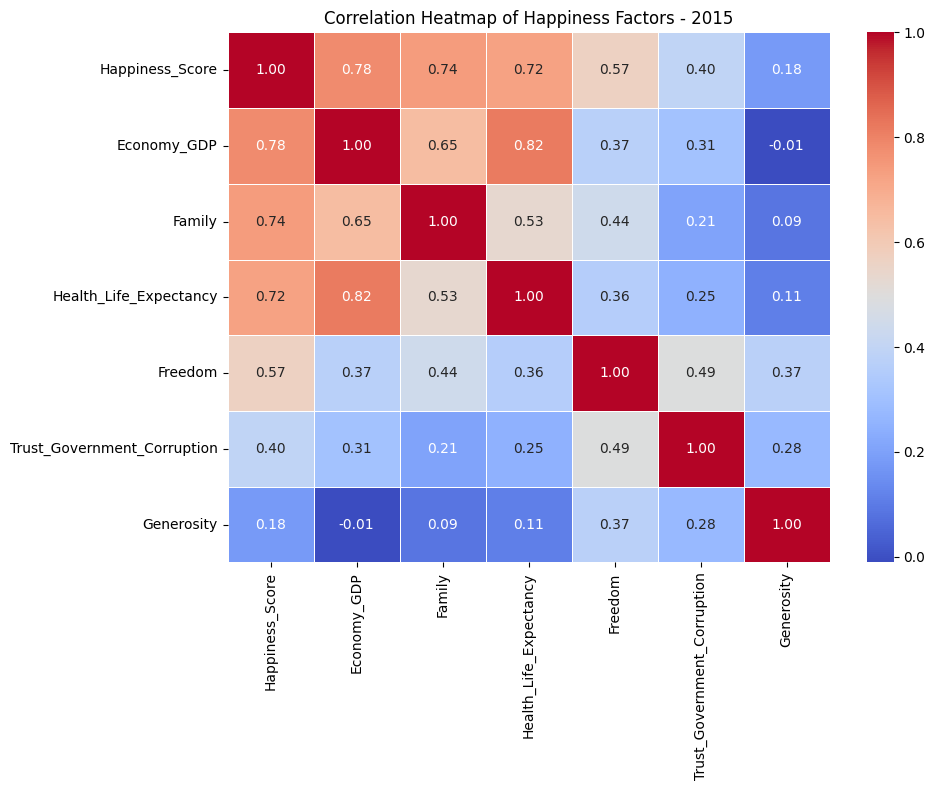

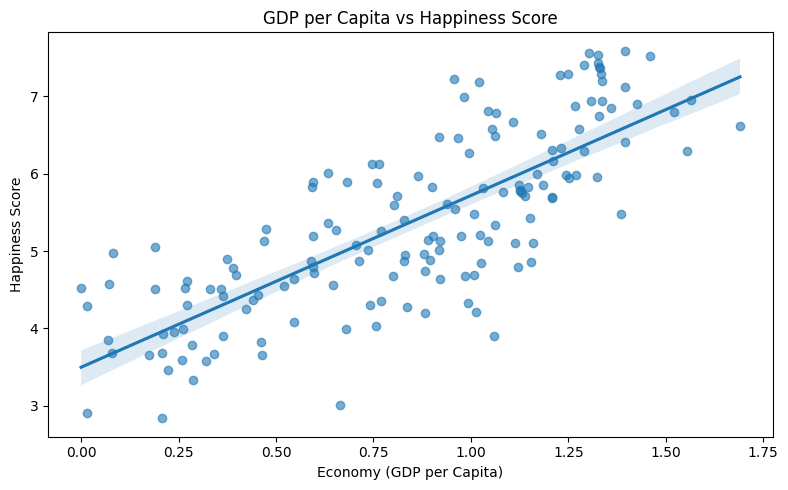

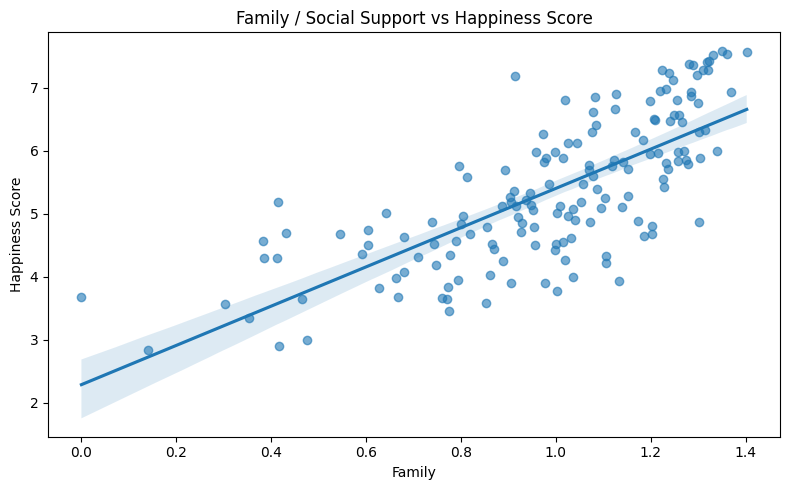

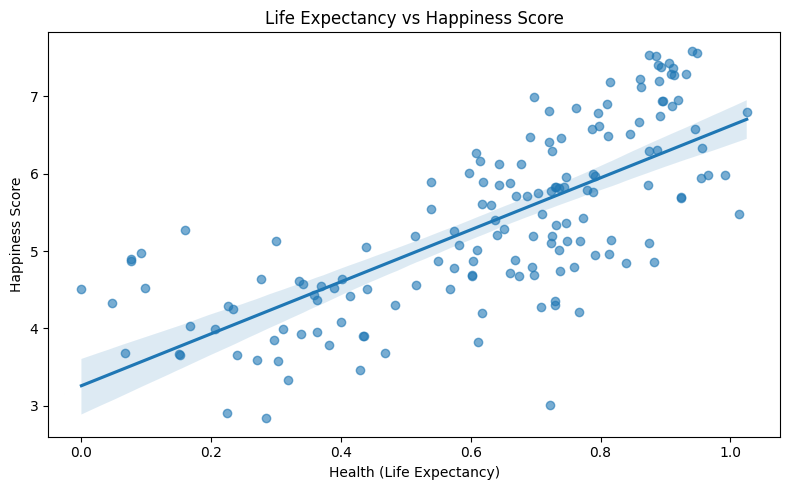

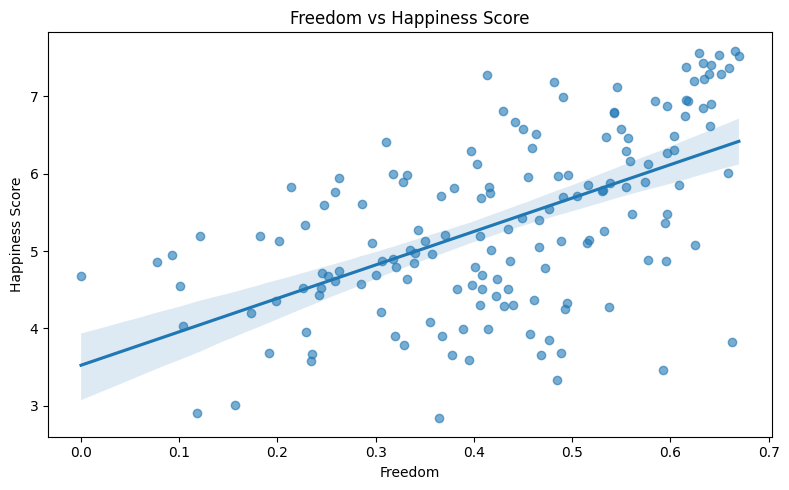

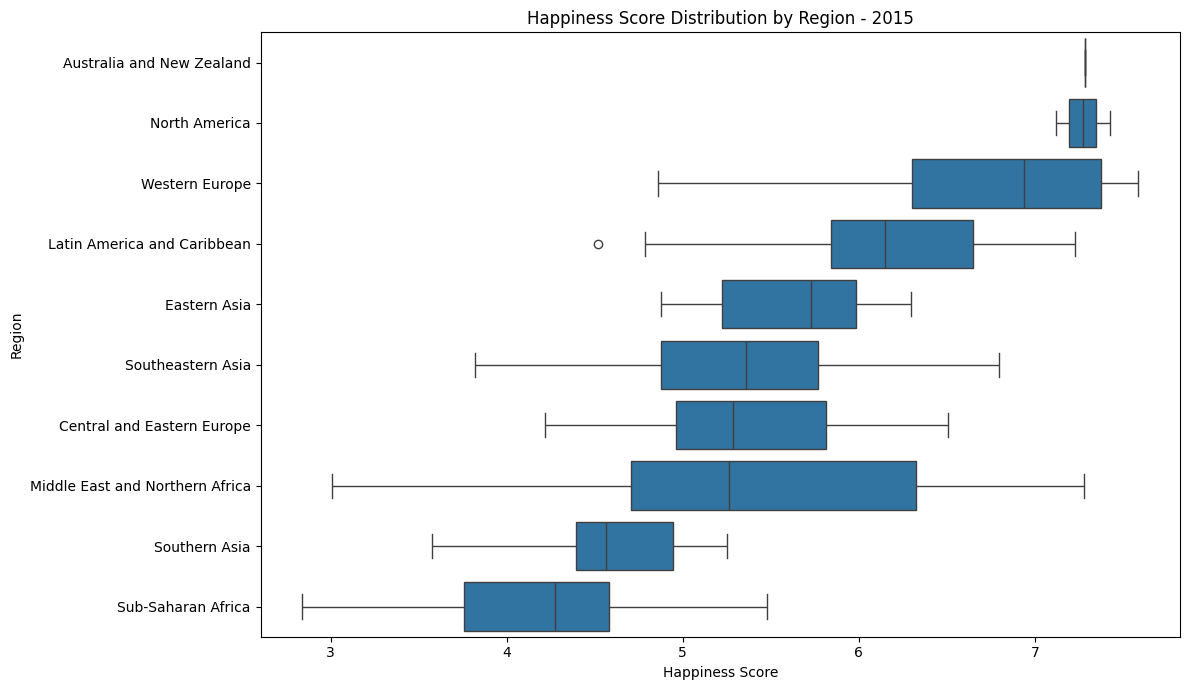


HAPPINESS ANALYSIS RESULTS

Average Happiness Score: 5.38
Highest Happiness Score: 7.59
Lowest Happiness Score: 2.84

Happiest Country: Switzerland
Least Happy Country: Togo

Analysis completed successfully!


In [15]:
# =========================================================
# 1. LOAD DATASET
# =========================================================

file_path = "2015.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)


# =========================================================
# 2. CLEAN COLUMN NAMES
# =========================================================

df.columns = df.columns.str.strip()

print("\nOriginal Columns:")
print(df.columns.tolist())


# =========================================================
# 3. RENAME COLUMNS
# =========================================================

column_mapping = {}

for col in df.columns:

    clean_col = col.lower().strip()

    if "happiness score" in clean_col:
        column_mapping[col] = "Happiness_Score"

    elif "economy" in clean_col and "gdp" in clean_col:
        column_mapping[col] = "Economy_GDP"

    elif "family" in clean_col:
        column_mapping[col] = "Family"

    elif "health" in clean_col and "life" in clean_col:
        column_mapping[col] = "Health_Life_Expectancy"

    elif "freedom" in clean_col:
        column_mapping[col] = "Freedom"

    elif "trust" in clean_col or "government corruption" in clean_col:
        column_mapping[col] = "Trust_Government_Corruption"

    elif "generosity" in clean_col:
        column_mapping[col] = "Generosity"

    elif "region" in clean_col:
        column_mapping[col] = "Region"


df.rename(columns=column_mapping, inplace=True)

print("\nCleaned Columns:")
print(df.columns.tolist())


# =========================================================
# 4. CHECK REQUIRED COLUMNS
# =========================================================

required_columns = [
    "Happiness_Score",
    "Economy_GDP",
    "Family",
    "Health_Life_Expectancy",
    "Freedom",
    "Trust_Government_Corruption",
    "Generosity"
]

missing_columns = []

for column in required_columns:

    if column not in df.columns:
        missing_columns.append(column)


if len(missing_columns) > 0:

    print("\nRequired columns not found:")
    print(missing_columns)

    print("\nYour CSV contains:")
    print(df.columns.tolist())

else:

    print("\nAll required columns found!")


# =========================================================
# 5. CONVERT NUMERIC COLUMNS
# =========================================================

for column in required_columns:

    if column in df.columns:

        df[column] = pd.to_numeric(
            df[column],
            errors="coerce"
        )


# =========================================================
# 6. MISSING VALUES
# =========================================================

print("\nMissing Values:")

print(df.isnull().sum())


# =========================================================
# 7. REMOVE EMPTY ROWS
# =========================================================

df = df.dropna(
    subset=required_columns
)

print("\nShape after cleaning:")
print(df.shape)


# =========================================================
# 8. CORRELATION MATRIX
# =========================================================

corr_matrix = df[required_columns].corr()


# =========================================================
# 9. CORRELATION HEATMAP
# =========================================================

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title(
    "Correlation Heatmap of Happiness Factors - 2015"
)

plt.tight_layout()

plt.show()


# =========================================================
# 10. GDP VS HAPPINESS
# =========================================================

plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="Economy_GDP",
    y="Happiness_Score",
    scatter_kws={"alpha": 0.6}
)

plt.title(
    "GDP per Capita vs Happiness Score"
)

plt.xlabel(
    "Economy (GDP per Capita)"
)

plt.ylabel(
    "Happiness Score"
)

plt.tight_layout()

plt.show()


# =========================================================
# 11. FAMILY VS HAPPINESS
# =========================================================

plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="Family",
    y="Happiness_Score",
    scatter_kws={"alpha": 0.6}
)

plt.title(
    "Family / Social Support vs Happiness Score"
)

plt.xlabel(
    "Family"
)

plt.ylabel(
    "Happiness Score"
)

plt.tight_layout()

plt.show()


# =========================================================
# 12. HEALTH VS HAPPINESS
# =========================================================

plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="Health_Life_Expectancy",
    y="Happiness_Score",
    scatter_kws={"alpha": 0.6}
)

plt.title(
    "Life Expectancy vs Happiness Score"
)

plt.xlabel(
    "Health (Life Expectancy)"
)

plt.ylabel(
    "Happiness Score"
)

plt.tight_layout()

plt.show()


# =========================================================
# 13. FREEDOM VS HAPPINESS
# =========================================================

plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="Freedom",
    y="Happiness_Score",
    scatter_kws={"alpha": 0.6}
)

plt.title(
    "Freedom vs Happiness Score"
)

plt.xlabel(
    "Freedom"
)

plt.ylabel(
    "Happiness Score"
)

plt.tight_layout()

plt.show()


# =========================================================
# 14. REGIONAL COMPARISON
# =========================================================

if "Region" in df.columns:

    region_order = (
        df.groupby("Region")["Happiness_Score"]
        .median()
        .sort_values(ascending=False)
        .index
    )

    plt.figure(figsize=(12, 7))

    sns.boxplot(
        data=df,
        x="Happiness_Score",
        y="Region",
        order=region_order
    )

    plt.title(
        "Happiness Score Distribution by Region - 2015"
    )

    plt.xlabel(
        "Happiness Score"
    )

    plt.ylabel(
        "Region"
    )

    plt.tight_layout()

    plt.show()


# =========================================================
# 15. BASIC ANALYSIS
# =========================================================

print("\n" + "=" * 50)
print("HAPPINESS ANALYSIS RESULTS")
print("=" * 50)

print(
    "\nAverage Happiness Score:",
    round(df["Happiness_Score"].mean(), 2)
)

print(
    "Highest Happiness Score:",
    round(df["Happiness_Score"].max(), 2)
)

print(
    "Lowest Happiness Score:",
    round(df["Happiness_Score"].min(), 2)
)


# =========================================================
# 16. HAPPIEST COUNTRY
# =========================================================

if "Country" in df.columns:

    highest_index = df["Happiness_Score"].idxmax()

    print(
        "\nHappiest Country:",
        df.loc[highest_index, "Country"]
    )


# =========================================================
# 17. LEAST HAPPY COUNTRY
# =========================================================

if "Country" in df.columns:

    lowest_index = df["Happiness_Score"].idxmin()

    print(
        "Least Happy Country:",
        df.loc[lowest_index, "Country"]
    )


print("\n" + "=" * 50)
print("Analysis completed successfully!")
print("=" * 50)